<a href="https://colab.research.google.com/github/Asaf-Greenfield-2/ML4P_Asaf_3/blob/main/Asaf_ML4P_PS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from astropy.io import fits
import pylab as plt

In [3]:
path_labels = "/content/drive/MyDrive/PS1_ML4P_Asaf's/Copy of labels.fits"
allstar = fits.open(path_labels)

(5.0, 0.0)

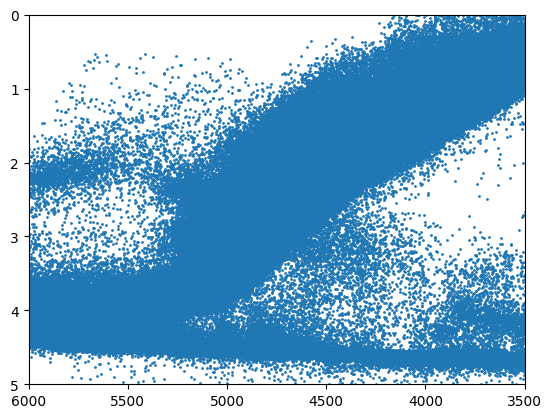

In [4]:
# the labels are in an enormous table in element [1] of this FITS file
labels = allstar[1].data
plt.scatter(labels['TEFF'], labels['LOGG'], s=1)
plt.xlim(6000, 3500)
plt.ylim(5, 0)

In [5]:
# make a reasonable red-giant-branch sample
RGB = True
RGB = np.logical_and(RGB, labels['TEFF'] > 3500.)
RGB = np.logical_and(RGB, labels['TEFF'] < 5400.)
RGB = np.logical_and(RGB, labels['LOGG'] < 3.0)
RGB = np.logical_and(RGB, labels['LOGG'] > 0.0)
RGB = np.logical_and(RGB, labels['H'] < 10.5)
print(np.sum(RGB))

145991


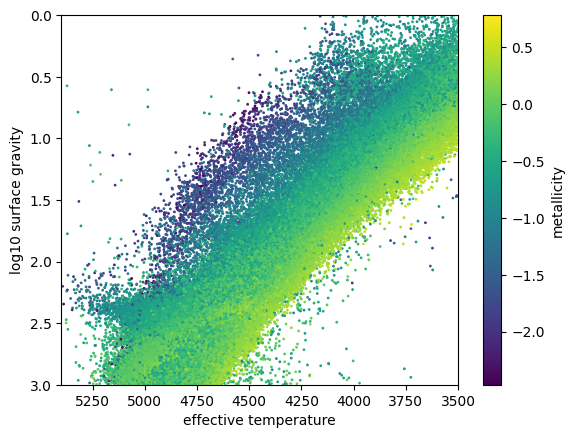

In [6]:
# make a plot that an astronomer likes to see
RGB_labels = labels[RGB]
plt.scatter(RGB_labels['TEFF'], RGB_labels['LOGG'], c=RGB_labels['FE_H'], s=1)
plt.xlim(5400, 3500)
plt.xlabel("effective temperature")
plt.ylim(3., 0.)
plt.ylabel("log10 surface gravity")
plt.colorbar(label="metallicity")

In [7]:
# make train, validation, and test data sets
rng = np.random.default_rng(17)
N_RGB = len(RGB_labels)
N_train, N_valid, N_test = 1024, 256, 512
I = rng.permutation(N_RGB)
I_train = I[0:N_train]
I_valid = I[N_train:N_train+N_valid]
I_test = I[N_train+N_valid:N_train+N_valid+N_test]

train_labels = RGB_labels[I_train]
valid_labels = RGB_labels[I_valid]
test_labels = RGB_labels[I_test]
print(len(train_labels), len(valid_labels), len(test_labels))

1024 256 512


In [8]:
train_labels_logg = train_labels['LOGG']
valid_labels_logg = valid_labels['LOGG']
test_labels_logg = test_labels['LOGG']
print(train_labels_logg.shape, valid_labels_logg.shape, test_labels_logg.shape)

(1024,) (256,) (512,)


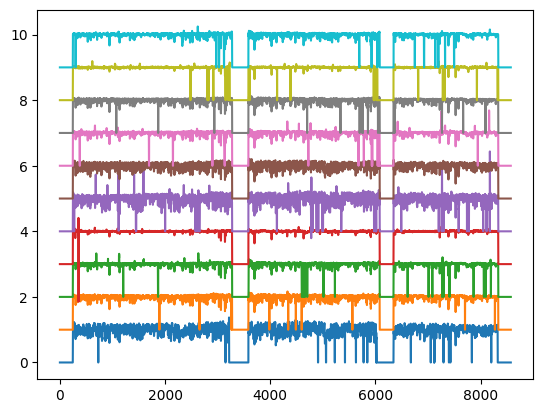

In [9]:
train_features = np.load("/content/drive/MyDrive/PS1_ML4P_Asaf's/Copy of train_features.npy")
valid_features = np.load("/content/drive/MyDrive/PS1_ML4P_Asaf's/Copy of valid_features.npy")
test_features = np.load("/content/drive/MyDrive/PS1_ML4P_Asaf's/Copy of test_features.npy")
for i in range(10):
    plt.plot(train_features[i] + i)

In [10]:
print(train_features.shape) # (num_spectra, num_pixels)

(1024, 8575)


alpha: 1.0
train rmse: 0.03876370370345609
train r2: 0.9969729818900062


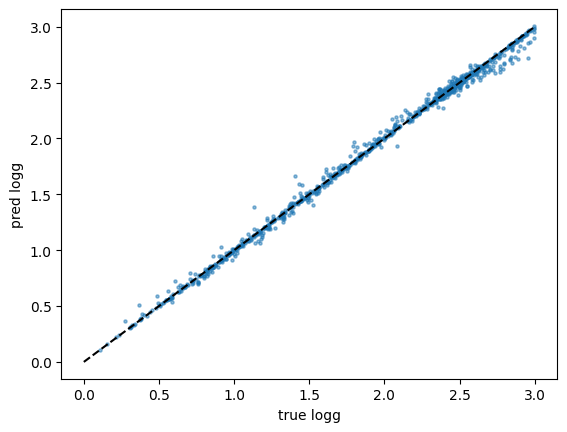

In [11]:
# TRAINING for Linear Regression

# since features (8575) are much greater than the amount of data (1024), added regularization

from sklearn.linear_model import Ridge
import numpy as np
import matplotlib.pyplot as plt

# labels as  floats
y_train = np.array(train_labels_logg, dtype=float).ravel()

# fit ridge regression on the training spectra
alpha = 1.0
model = Ridge(alpha=alpha)
model.fit(train_features, y_train)

# see how it does on train
pred = model.predict(train_features)
rmse = np.sqrt(np.mean((y_train - pred)**2))
print("alpha:", alpha)
print("train rmse:", rmse)
print("train r2:", model.score(train_features, y_train))

# predicted vs true
plt.scatter(y_train, pred, s=5, alpha=0.5)
plt.plot([0, 3], [0, 3], 'k--')
plt.xlabel("true logg")
plt.ylabel("pred logg")
plt.show()


In [12]:
# check the alpha=1.0 model on VALIDATION

y_valid = np.array(valid_labels_logg, dtype=float).ravel()
vpred = model.predict(valid_features)
vrmse = np.sqrt(np.mean((y_valid - vpred)**2))
print("alpha:", alpha)
print("valid rmse:", vrmse)
print("valid r2:", model.score(valid_features, y_valid))

# sweep alpha
for a in [0.1, 1, 10, 100, 1000, 10000]:
    m = Ridge(alpha=a)
    m.fit(train_features, y_train)
    p = m.predict(valid_features)
    r = np.sqrt(np.mean((y_valid - p)**2))
    print("alpha:", a, "valid rmse:", r)

alpha: 1.0
valid rmse: 0.23182119461135076
valid r2: 0.8810481547736064
alpha: 0.1 valid rmse: 0.29046940390398834
alpha: 1 valid rmse: 0.23182119461135076
alpha: 10 valid rmse: 0.21538157347667405
alpha: 100 valid rmse: 0.23308334774032072
alpha: 1000 valid rmse: 0.30529277937513083
alpha: 10000 valid rmse: 0.4724574646579695


alpha: 10
test rmse: 0.1980889335654386
test r2: 0.9148552957252429


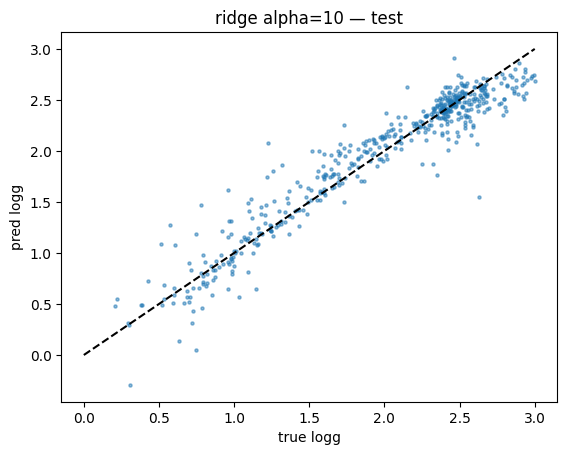

In [13]:
# lock in alpha = 10 (best on validation), final test evaluation
y_test = np.array(test_labels_logg, dtype=float).ravel()

model = Ridge(alpha=10)
model.fit(train_features, y_train)

# evaluate on the test set (only doing this once)
tpred = model.predict(test_features)
trmse = np.sqrt(np.mean((y_test - tpred)**2))
print("alpha:", 10)
print("test rmse:", trmse)
print("test r2:", model.score(test_features, y_test))

# predicted vs true on test
plt.scatter(y_test, tpred, s=5, alpha=0.5)
plt.plot([0, 3], [0, 3], 'k--')
plt.xlabel("true logg")
plt.ylabel("pred logg")
plt.title("ridge alpha=10 — test")
plt.show()

# baseline: linear regression (ridge), test rmse ~0.2 dex

In [14]:
#b: K-Nearest-Neighbors Training

from sklearn.neighbors import KNeighborsRegressor

# knn on the training spectra, predicting logg
k = 5
model = KNeighborsRegressor(n_neighbors=k)
model.fit(train_features, y_train)

# how it does on train
pred = model.predict(train_features)
rmse = np.sqrt(np.mean((y_train - pred)**2))
print("k:", k)
print("train rmse:", rmse)
print("train r2:", model.score(train_features, y_train))

# try a few k on validation, pick best
for k in [1, 3, 5, 10, 20, 50]:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(train_features, y_train)
    p = m.predict(valid_features)
    r = np.sqrt(np.mean((y_valid - p)**2))
    print("k:", k, "valid rmse:", r)

# knn uses distance between spectra; features are all flux so scales are comparable

k: 5
train rmse: 0.19405129031138318
train r2: 0.9241426689784371
k: 1 valid rmse: 0.2958590961382625
k: 3 valid rmse: 0.24201778707329086
k: 5 valid rmse: 0.22628248362620887
k: 10 valid rmse: 0.2271311475683849
k: 20 valid rmse: 0.2405063185467584
k: 50 valid rmse: 0.2736580213752323


k: 5
test rmse: 0.2289419105031637
test r2: 0.8862666532824718


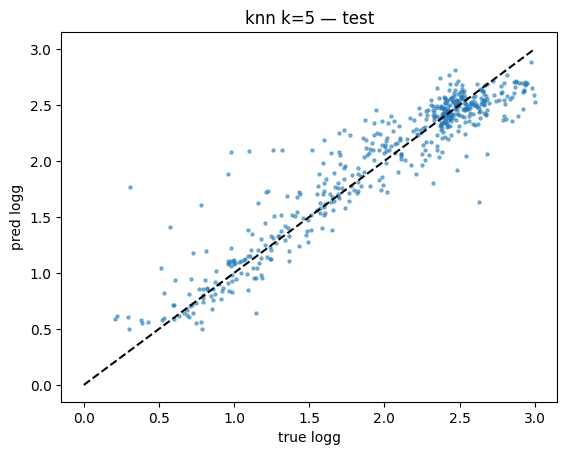

In [15]:
# lock in k = 5 (best on validation), final TEST evaluation
model = KNeighborsRegressor(n_neighbors=5)
model.fit(train_features, y_train)

# evaluate on the test set (only doing this once)
tpred = model.predict(test_features)
trmse = np.sqrt(np.mean((y_test - tpred)**2))
print("k:", 5)
print("test rmse:", trmse)
print("test r2:", model.score(test_features, y_test))

# predicted vs true on test
plt.scatter(y_test, tpred, s=5, alpha=0.5)
plt.plot([0, 3], [0, 3], 'k--')
plt.xlabel("true logg")
plt.ylabel("pred logg")
plt.title("knn k=5 — test")
plt.show()

# knn (k=5), test rmse ~0.22 dex -- slightly worse than ridge baseline

train rmse: 0.006006449075425681
train r2: 0.9999273224820081


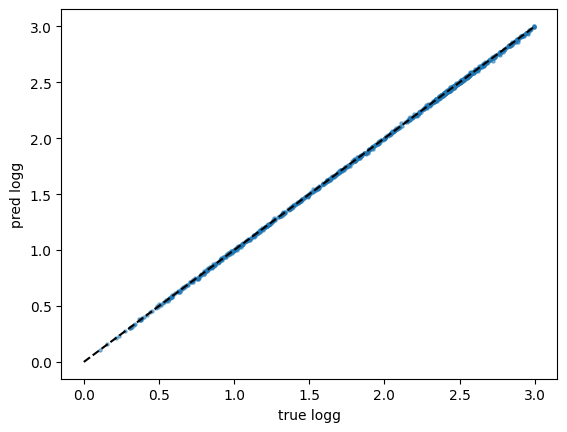

In [19]:
#Multi Layer Perceptron TRAINING (lbfgs solver)
from sklearn.neural_network import MLPRegressor
# lbfgs converges way better than the default adam on small data like ours (1024 stars)
model = MLPRegressor(hidden_layer_sizes=(64,),
                     solver='lbfgs',        # the fix - default adam wasn't converging
                     alpha=1.0,
                     random_state=17,
                     max_iter=2000)
model.fit(train_features_s, y_train)
pred = model.predict(train_features_s)
rmse = np.sqrt(np.mean((y_train - pred)**2))
print("train rmse:", rmse)
print("train r2:", model.score(train_features_s, y_train))
plt.scatter(y_train, pred, s=5, alpha=0.5)
plt.plot([0, 3], [0, 3], 'k--')
plt.xlabel("true logg")
plt.ylabel("pred logg")
plt.show()

In [20]:
#Multi Layer Perceptron VALIDATION (lbfgs solver)
# scale valid with the SAME scaler fit on train
valid_features_s = scaler.transform(valid_features)
# check current model on validation
vpred = model.predict(valid_features_s)
print("alpha:", 1.0, "valid rmse:", np.sqrt(np.mean((y_valid - vpred)**2)),
      "valid r2:", model.score(valid_features_s, y_valid))
# short alpha sweep, lbfgs
for a in [0.1, 1, 10, 100]:
    m = MLPRegressor(hidden_layer_sizes=(64,), solver='lbfgs', alpha=a,
                     random_state=17, max_iter=2000)
    m.fit(train_features_s, y_train)
    p = m.predict(valid_features_s)
    r = np.sqrt(np.mean((y_valid - p)**2))
    print("alpha:", a, "valid rmse:", r)

alpha: 1.0 valid rmse: 0.23010851624478115 valid r2: 0.8827992776150774


KeyboardInterrupt: 

test rmse: 0.22206746521636106
test r2: 0.8929942576461342


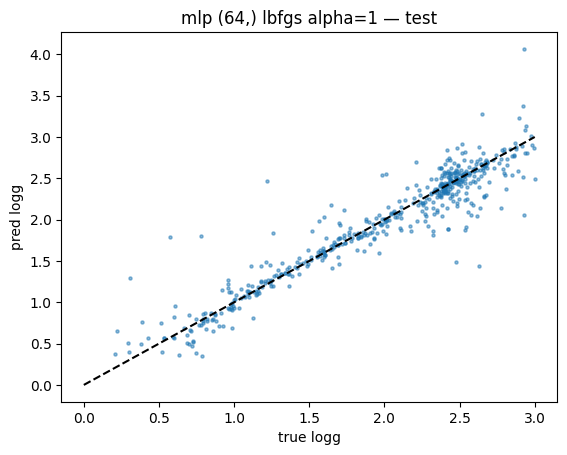

In [21]:
#Multi Layer Perceptron TEST
# lock in alpha=1.0, lbfgs, (64,) - validation rmse was ~0.23
test_features_s = scaler.transform(test_features)   # same scaler, no refit

model = MLPRegressor(hidden_layer_sizes=(64,), solver='lbfgs', alpha=1.0,
                     random_state=17, max_iter=2000)
model.fit(train_features_s, y_train)

# evaluate on test (only once)
tpred = model.predict(test_features_s)
trmse = np.sqrt(np.mean((y_test - tpred)**2))
print("test rmse:", trmse)
print("test r2:", model.score(test_features_s, y_test))

plt.scatter(y_test, tpred, s=5, alpha=0.5)
plt.plot([0, 3], [0, 3], 'k--')
plt.xlabel("true logg")
plt.ylabel("pred logg")
plt.title("mlp (64,) lbfgs alpha=1 — test")
plt.show()

In [22]:
#PART 2: linear hyperparameter tuning
# trying a couple different things to see what helps on validation

# 1. plain linear regression, no regularization
from sklearn.linear_model import LinearRegression
m = LinearRegression()
m.fit(train_features, y_train)
p = m.predict(valid_features)
print("plain linear, valid rmse:", np.sqrt(np.mean((y_valid - p)**2)))

# 2. ridge, sweep alpha (the regularization strength)
for a in [1, 10, 100]:
    m = Ridge(alpha=a)
    m.fit(train_features, y_train)
    p = m.predict(valid_features)
    print("ridge alpha", a, "valid rmse:", np.sqrt(np.mean((y_valid - p)**2)))

# 3. ridge alpha=10 but scale the features first
m = Ridge(alpha=10)
m.fit(train_features_s, y_train)   # train_features_s is the scaled version from the MLP part
p = m.predict(scaler.transform(valid_features))
print("ridge alpha 10 + scaling, valid rmse:", np.sqrt(np.mean((y_valid - p)**2)))



#I tried plain linear regression without any penalty to see it overfit and the validation came out worse. So the ridge penalty and regularization is better
#I sweeped alpha to see the difference that it makes, and i picked 10 because it had a minimum ther
#I scaled the features,but it made it worse

plain linear, valid rmse: 0.3371730887249423
ridge alpha 1 valid rmse: 0.23182119461135076
ridge alpha 10 valid rmse: 0.21538157347667405
ridge alpha 100 valid rmse: 0.23308334774032072
ridge alpha 10 + scaling, valid rmse: 0.35863897043863474


In [23]:
#PART 2: knn hyperparameter tuning
# try a few k on validation
for k in [1, 3, 5, 10, 20]:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(train_features, y_train)
    p = m.predict(valid_features)
    print("k", k, "valid rmse:", np.sqrt(np.mean((y_valid - p)**2)))

# rerun best k with different RNG seeds (per the PDF)
for s in [0, 17, 42]:
    m = KNeighborsRegressor(n_neighbors=5)
    rng = np.random.default_rng(s)   # seed does nothing here, knn has no randomness
    m.fit(train_features, y_train)
    p = m.predict(valid_features)
    print("seed", s, "valid rmse:", np.sqrt(np.mean((y_valid - p)**2)))

    #k=5 was the best when i varied it, k=1 I think was noisy and k being too large did not work
    #The seeds didnt change anything because it will have the same neighbors every time

k 1 valid rmse: 0.2958590961382625
k 3 valid rmse: 0.24201778707329086
k 5 valid rmse: 0.22628248362620887
k 10 valid rmse: 0.2271311475683849
k 20 valid rmse: 0.2405063185467584
seed 0 valid rmse: 0.22628248362620887
seed 17 valid rmse: 0.22628248362620887
seed 42 valid rmse: 0.22628248362620887


In [24]:
#PART 2: mlp hyperparameter tuning
# try a few things on validation (scaled features, lbfgs)
for hl in [(32,), (64,), (128,)]:
    m = MLPRegressor(hidden_layer_sizes=hl, solver='lbfgs', alpha=1.0,
                     random_state=17, max_iter=2000)
    m.fit(train_features_s, y_train)
    p = m.predict(valid_features_s)
    print("layers", hl, "valid rmse:", np.sqrt(np.mean((y_valid - p)**2)))

# rerun best setup with different RNG seeds (per the PDF)
for s in [0, 17, 42]:
    m = MLPRegressor(hidden_layer_sizes=(64,), solver='lbfgs', alpha=1.0,
                     random_state=s, max_iter=2000)
    m.fit(train_features_s, y_train)
    p = m.predict(valid_features_s)
    print("seed", s, "valid rmse:", np.sqrt(np.mean((y_valid - p)**2)))

    #I switched to lbfgs instead of Adam which was the real improvement
    #Switching the architecture didn't make a big difference once I used lbfgs
    #I sweeped alpha and alpha = 1 was the best
    #The seed changed the answer beacuse the MLP is random


layers (32,) valid rmse: 0.2554957960143881
layers (64,) valid rmse: 0.23010851624478115
layers (128,) valid rmse: 0.23709586218923132
seed 0 valid rmse: 0.26034550951028046
seed 17 valid rmse: 0.23010851624478115
seed 42 valid rmse: 0.2509490617766978


In [23]:
#My initial thoughts for a project are to derive a physical law from data,
#for example to feed data from a system into a symbolic regressor
#And show it recovers the actual equation. I would use PYSR for it

In [ ]:
#I used Claude Code for help with the code in this project